In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

from mplsoccer import Sbopen, Pitch

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

parser = Sbopen()
df_competition = parser.competition()

# 경기 이벤트 데이터 불러오기
df_event, df_realted, df_freeze, df_tactics = parser.event(3857299)

# 대한민국 데이터만 필터링 (대괄로 감싸는건 필수)
df_kor_event = df_event[df_event['team_name'] == 'South Korea']

# 가나 데이터만 필터링 
df_gn_event = df_event[df_event['team_name'] == 'Ghana']
# 이벤트 개수 확인
print(len(df_kor_event))
print(len(df_gn_event))


2008
1338


In [8]:
# 교체 발생 필터링
kor_sub_events = df_kor_event[df_kor_event['type_name'] == 'Substitution']
gn_sub_events = df_gn_event[df_gn_event['type_name'] == "Substitution"]

# 첫 교체 시간 구하기
first_kor_sub_min = kor_sub_events.iloc[0]['minute']
first_gn_sub_min = gn_sub_events.iloc[0]['minute']

print(f"대한민국 첫 교체 시간: {first_kor_sub_min}분")
print(f"가나 첫 교체 시간: {first_gn_sub_min}분")

대한민국 첫 교체 시간: 45분
가나 첫 교체 시간: 77분


In [12]:
# 첫 교제 대신 실제 전반전, 후반전 전체로 다시 필터링

kor_first_half = df_kor_event[df_kor_event['period'] == 1]
gn_first_half = df_gn_event[df_gn_event['period'] == 1]

kor_second_half = df_kor_event[df_kor_event['period'] == 2]
gn_second_half = df_gn_event[df_gn_event['period'] == 2]

kor_passes_h1 = kor_first_half[
    (df_kor_event['type_name'] == 'Pass') &
    (df_kor_event['outcome_name'].isna())
]
gn_passes_h1 = gn_first_half[
    (df_gn_event['type_name'] == 'Pass') &
    (df_gn_event['outcome_name'].isna())
]

print(f"대한민국 전반전 성공 패스 수: {len(kor_passes_h1)}")
print(f"가나 전반전 성공 패스 수: {len(gn_passes_h1)}")

대한민국 전반전 성공 패스 수: 252
가나 전반전 성공 패스 수: 166


In [7]:
# 대한민국 선수별 평균 좌표 계산하기
kor_player_coords = kor_passes_h1.groupby('player_name')[['x', 'y']].mean().reset_index()
# 가나 선수별 평균 좌표 계산하기
gn_player_coords = gn_passes_h1.groupby('player_name')[['x', 'y']].mean().reset_index() 

print(f'대한민국 선발 인원수: {len(kor_player_coords)}명')
print(f'가나 선발 인원수: {len(gn_player_coords)}명')

대한민국 선발 인원수: 11명
가나 선발 인원수: 11명


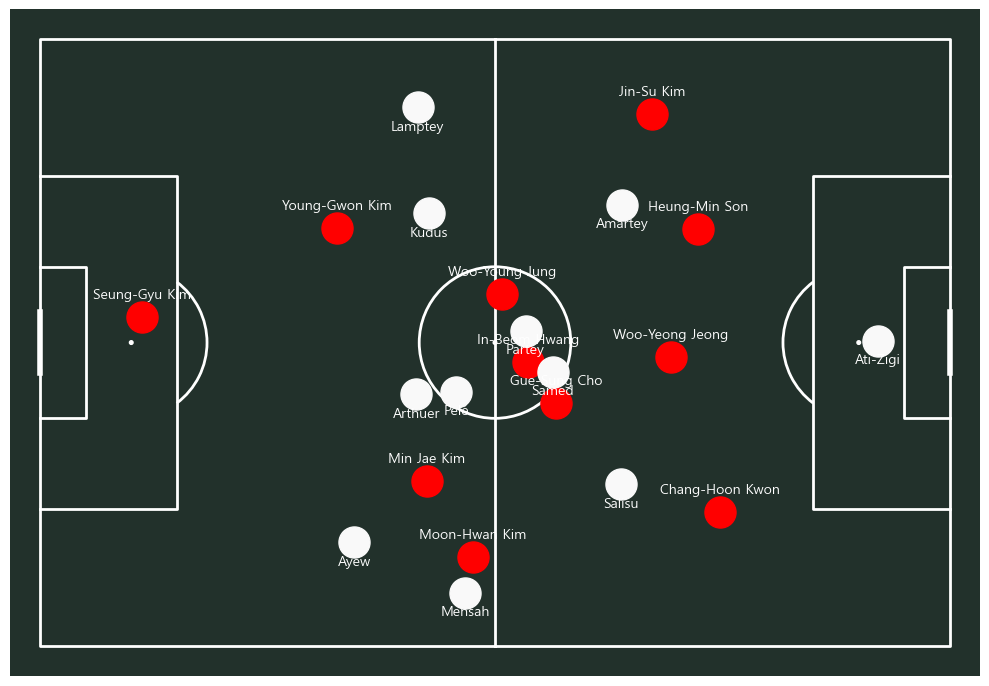

In [13]:
pitch = Pitch(pitch_type='statsbomb' , pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(10,7))

# 1. 대한민국 (붉은색 점 찍기)
pitch.scatter(
    kor_player_coords['x'], 
    kor_player_coords['y'], 
    s=500, 
    color='red', 
    ax=ax
    )

# 1-1. 가나 (흰색 점 찍기)
pitch.scatter(
    120-gn_player_coords['x'], 
    80-gn_player_coords['y'], 
    s=500, 
    color='#f9f9f9', 
    ax=ax
    )

# 2. 대한민국 선수 이름 표시 (반복문으로 채우기)
for idx, row in kor_player_coords.iterrows():
    pitch.annotate(
        text=row['player_name'],
        xy=(row['x'], row['y'] - 2.5),
        c='white', ha='center', ax= ax
    )
# 2-1. 가나 선수 이름 표시 
for idx, row in gn_player_coords.iterrows():
    pitch.annotate(
        text=row['player_name'].split()[-1],
        xy=(120-row['x'], 80-row['y'] + 3),
        c='white', ha='center', ax= ax
    )  

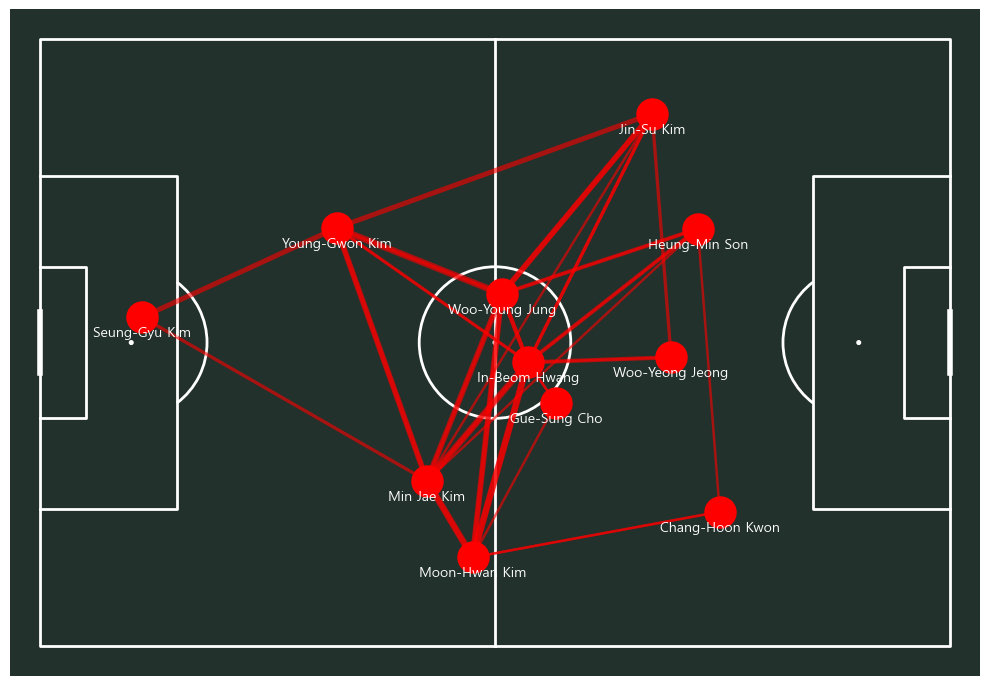

In [16]:
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

# 선수들간의 패스 횟수
kor_passes_between = kor_passes_h1.groupby(['player_name', 'pass_recipient_name']).size().reset_index(name='pass_count')

# 패스 횟수를 1 ~ 2회 정도로 하면 선이 너무 많아져서 지저분해질수 있기때문에 4회 정도로 설정
kor_passes_between = kor_passes_between[kor_passes_between['pass_count'] > 2]

# 패스 횟수 표에 선수들의 평균 좌표(x,y) 합치기
# 1. 패스 보낸 사람(player_name)의 평균 x,y 좌표 붙이기
kor_passes_between = kor_passes_between.merge(kor_player_coords, on='player_name')

# 2. 패스 받은 사람 (pass_recipient_name)의 평균 x,y 좌표 붙이기
# (이때 x, y 컬럼명이 겹치므로 각각 x_end, y_end 같은 이름으로 들어감)
kor_passes_between = kor_passes_between.merge(kor_player_coords, left_on='pass_recipient_name', right_on='player_name', suffixes=('', '_end'))


# 1. 대한민국 (붉은 점 찍기)
pitch.scatter(
    kor_player_coords['x'], 
    kor_player_coords['y'], 
    s=500, 
    color='red', 
    ax=ax
)
# 2. 대한민국 선수 이름 표시 (반복문으로 채우기)
for idx, row in kor_player_coords.iterrows():
    pitch.annotate(
        text=row['player_name'],
        xy=(row['x'], row['y'] + 2.5),
        c='white', ha='center', ax= ax
)
# 3. 대한민국 패스 연결선
pitch.lines(
    kor_passes_between['x'], kor_passes_between['y'], # 시작점 (패스 보낸 사람 좌표)
    kor_passes_between['x_end'], kor_passes_between['y_end'], # 끝점 (패스 받은 사람 좌표)
    linewidth=kor_passes_between['pass_count'] * 0.6,         # 패스 횟수에 비례해서 선 두께 조절
    color='red',
    alpha=0.6,                                                  # 선 투명도
    ax=ax

)
plt.show()   

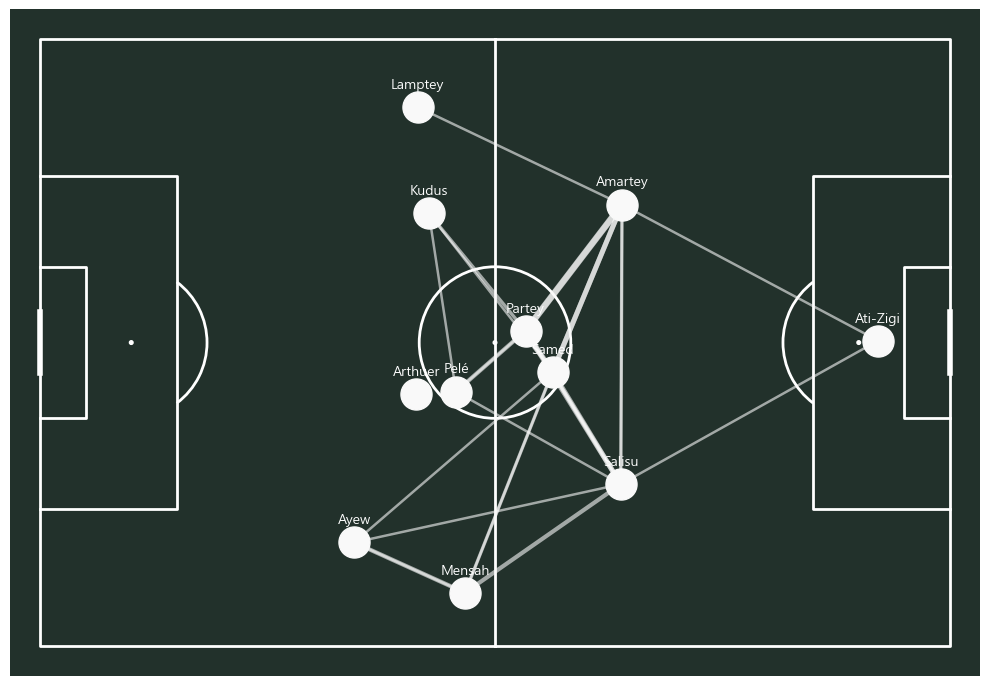

In [19]:
pitch = Pitch(pitch_type='statsbomb' , pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(10,7))

# 가나 패스맵
gn_passes_between = gn_passes_h1.groupby(['player_name', 'pass_recipient_name']).size().reset_index(name='pass_count')

gn_passes_between = gn_passes_between[gn_passes_between['pass_count'] > 2]

gn_passes_between = gn_passes_between.merge(gn_player_coords, on='player_name')

gn_passes_between = gn_passes_between.merge(gn_player_coords, left_on='pass_recipient_name', right_on='player_name', suffixes=('', '_end'))


# 1. 가나 (흰색 점 찍기)
pitch.scatter(
    120-gn_player_coords['x'], 
    80-gn_player_coords['y'], 
    s=500, 
    color='#f9f9f9', 
    ax=ax
)
# 2. 가나 선수 이름 표시 
for idx, row in gn_player_coords.iterrows():
    pitch.annotate(
        text=row['player_name'].split()[-1],
        xy=(120-row['x'], 80-row['y'] - 2.5),
        c='white', ha='center', ax= ax
)
# 3. 가나 패스 연결선
pitch.lines(
    120-(gn_passes_between['x']), 80-gn_passes_between['y'], #오른쪽에 나타내기위해선 120에서 빼줘야한다.
    120-(gn_passes_between['x_end']), 80-gn_passes_between['y_end'], 
    linewidth=gn_passes_between['pass_count'] * 0.6,         
    color='#f9f9f9',
    alpha=0.6,                                                  
    ax=ax

)    
plt.show()